# Delaunay Triangulation via Flip Algorithm

This notebook demonstrates how to construct a **Delaunay triangulation** using the **Lawson edge-flip algorithm**:

1. **Build an initial triangulation** by incremental point insertion into a super-triangle (without flips), producing a valid but generally non-Delaunay triangulation.
2. **Iteratively flip illegal edges**: for each pair of adjacent triangles, check whether the shared edge satisfies the Delaunay condition (the circumcircle of one triangle does not contain the opposite vertex). If not, flip the edge.
3. **Repeat** until all edges are legal — the result is a Delaunay triangulation.

In [23]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.spatial import Voronoi
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [24]:
#generate random points
num_points = 20
points = np.random.rand(num_points, 2)

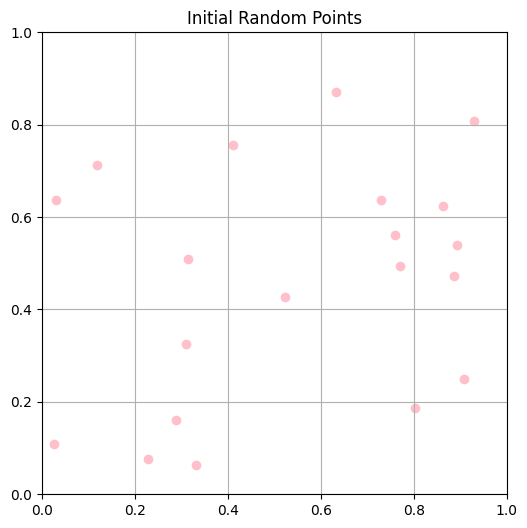

In [14]:
#visualize initial points
plt.figure(figsize=(6, 6))
plt.scatter(points[:, 0], points[:, 1], color='pink')
plt.title('Initial Random Points')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid()
plt.show()

In [25]:
# Geometry helpers and flip algorithm implementation
import copy
from scipy.spatial import ConvexHull

def orient2d(a, b, c):
    """Positive if a->b->c is counter-clockwise."""
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])

def point_in_triangle(p, a, b, c):
    """Check if point p is inside triangle abc (including boundary)."""
    d1 = orient2d(a, b, p)
    d2 = orient2d(b, c, p)
    d3 = orient2d(c, a, p)
    has_neg = (d1 < 0) or (d2 < 0) or (d3 < 0)
    has_pos = (d1 > 0) or (d2 > 0) or (d3 > 0)
    return not (has_neg and has_pos)

def in_circumcircle(pa, pb, pc, pd):
    """Check if pd is inside the circumcircle of CCW triangle (pa, pb, pc)."""
    ax_, ay_ = pa[0] - pd[0], pa[1] - pd[1]
    bx_, by_ = pb[0] - pd[0], pb[1] - pd[1]
    cx_, cy_ = pc[0] - pd[0], pc[1] - pd[1]
    det = (ax_*ax_ + ay_*ay_) * (bx_*cy_ - cx_*by_) \
        - (bx_*bx_ + by_*by_) * (ax_*cy_ - cx_*ay_) \
        + (cx_*cx_ + cy_*cy_) * (ax_*by_ - bx_*ay_)
    return det > 1e-10

def build_initial_triangulation(pts):
    """Build a valid (non-Delaunay) triangulation via convex hull fan + point insertion."""
    n = len(pts)
    hull = ConvexHull(pts)
    hull_verts = list(hull.vertices)

    # Fan triangulation of convex hull from vertex 0
    tris = []
    for i in range(1, len(hull_verts) - 1):
        tris.append([hull_verts[0], hull_verts[i], hull_verts[i + 1]])

    # Insert interior points by splitting containing triangle
    interior = [i for i in range(n) if i not in set(hull_verts)]
    for p_idx in interior:
        p = pts[p_idx]
        for t_idx in range(len(tris)):
            tri = tris[t_idx]
            if point_in_triangle(p, pts[tri[0]], pts[tri[1]], pts[tri[2]]):
                v0, v1, v2 = tri
                tris[t_idx] = [v0, v1, p_idx]
                tris.append([v1, v2, p_idx])
                tris.append([v2, v0, p_idx])
                break
    return tris

def find_adjacent(tris, t_idx, edge):
    """Find the triangle adjacent to tris[t_idx] across the given edge."""
    e = set(edge)
    for i, tri in enumerate(tris):
        if i != t_idx and e.issubset(set(tri)):
            return i
    return -1

def opposite_vertex(tri, edge):
    """Return the vertex of tri not on the edge."""
    for v in tri:
        if v not in edge:
            return v
    return -1

def lawson_flip(tris, pts):
    """Lawson's edge-flip algorithm.
    Returns history of triangulation states and flip info for visualization."""
    history = [copy.deepcopy(tris)]
    flip_info = [None]
    for _ in range(5000):
        found = False
        for t_idx in range(len(tris)):
            tri = tris[t_idx]
            for i in range(3):
                edge = (tri[i], tri[(i + 1) % 3])
                adj_idx = find_adjacent(tris, t_idx, edge)
                if adj_idx == -1:
                    continue
                a, b, c = tri
                pa, pb, pc = pts[a], pts[b], pts[c]
                if orient2d(pa, pb, pc) < 0:
                    a, c = c, a
                    pa, pc = pc, pa
                d = opposite_vertex(tris[adj_idx], edge)
                pd = pts[d]
                if in_circumcircle(pa, pb, pc, pd):
                    v_self = opposite_vertex(tri, edge)
                    e0, e1 = edge
                    s1 = orient2d(pts[v_self], pts[d], pts[e0])
                    s2 = orient2d(pts[v_self], pts[d], pts[e1])
                    if s1 * s2 < 0:  # quad is convex → safe to flip
                        tris[t_idx] = [v_self, d, e0]
                        tris[adj_idx] = [v_self, d, e1]
                        history.append(copy.deepcopy(tris))
                        flip_info.append((edge, (v_self, d)))
                        found = True
                        break
            if found:
                break
        if not found:
            break
    return history, flip_info

def get_edges(tris):
    """Extract all edges from a triangulation."""
    edges = set()
    for tri in tris:
        for i in range(3):
            e = tuple(sorted([tri[i], tri[(i + 1) % 3]]))
            edges.add(e)
    return edges

Initial triangulation: 31 triangles
Flips performed: 32


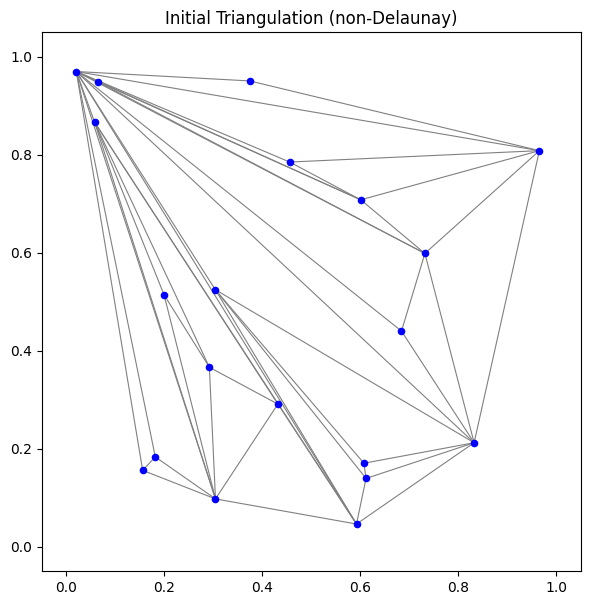

In [26]:
# Build initial triangulation and run flip algorithm
tris = build_initial_triangulation(points)
history, flip_info = lawson_flip(tris, points)

print(f"Initial triangulation: {len(history[0])} triangles")
print(f"Flips performed: {len(history) - 1}")

# Animate the flip process
fig, ax = plt.subplots(figsize=(7, 7))

def update(frame):
    ax.clear()
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_aspect('equal')

    edges = get_edges(history[frame])
    info = flip_info[frame]

    for e in edges:
        p1, p2 = points[e[0]], points[e[1]]
        color, lw = 'gray', 0.8
        if info:
            new_e = tuple(sorted(info[1]))
            if e == new_e:
                color, lw = 'green', 2.5
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, linewidth=lw)

    ax.scatter(points[:, 0], points[:, 1], color='blue', zorder=5, s=20)

    if frame == 0:
        ax.set_title('Initial Triangulation (non-Delaunay)')
    elif frame == len(history) - 1:
        ax.set_title(f'Delaunay Triangulation (after {len(history) - 1} flips)')
    else:
        ax.set_title(f'Flip {frame} / {len(history) - 1}')
    return []

ani = FuncAnimation(fig, update, frames=len(history), interval=500, blit=False, repeat=False)
HTML(ani.to_jshtml())

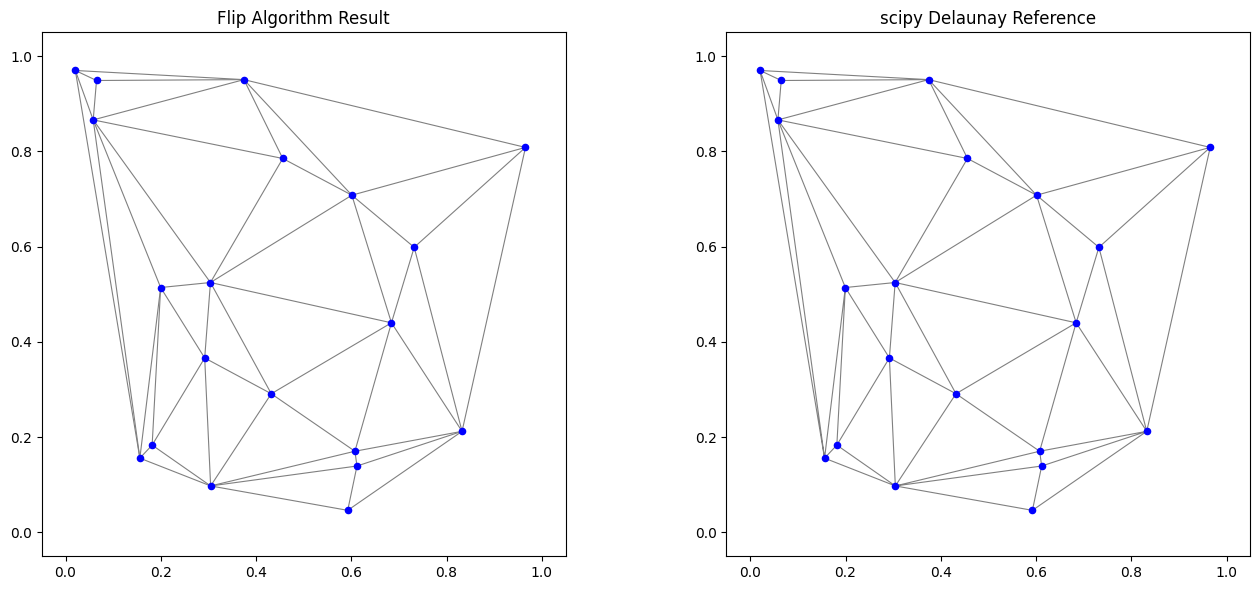

In [27]:
# Compare with scipy Delaunay to verify correctness
from scipy.spatial import Delaunay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Flip algorithm result
ax1 = axes[0]
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.set_aspect('equal')
ax1.set_title('Flip Algorithm Result')
for e in get_edges(history[-1]):
    p1, p2 = points[e[0]], points[e[1]]
    ax1.plot([p1[0], p2[0]], [p1[1], p2[1]], color='gray', linewidth=0.8)
ax1.scatter(points[:, 0], points[:, 1], color='blue', zorder=5, s=20)

# scipy Delaunay reference
ax2 = axes[1]
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.set_aspect('equal')
ax2.set_title('scipy Delaunay Reference')
dt = Delaunay(points)
ax2.triplot(points[:, 0], points[:, 1], dt.simplices, color='gray', linewidth=0.8)
ax2.scatter(points[:, 0], points[:, 1], color='blue', zorder=5, s=20)

plt.tight_layout()
plt.show()